In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

2025-10-22 18:40:58.368944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761158458.737871      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761158458.864413      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
dataset_path = "/kaggle/input/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification"
train_path = os.path.join(dataset_path, "train_images")
test_path = os.path.join(dataset_path, "test_images")

print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: /kaggle/input/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification/train_images
Test Path: /kaggle/input/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification/test_images


In [4]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3

In [ ]:

def analyze_dataset_structure(dataset_dir):
    classes = []
    class_counts = {}

    for class_folder in os.listdir(dataset_dir):
        class_path = os.path.join(dataset_dir, class_folder)
        if os.path.isdir(class_path):
            classes.append(class_folder)
            class_counts[class_folder] = len(os.listdir(class_path))

    print(f" Dataset: {dataset_dir}")
    print(f"Number of classes: {len(classes)}")
    print("Class distribution:")
    for class_name, count in class_counts.items():
        print(f" - {class_name}: {count} images")

    return classes, class_counts

# Run for training and test sets
train_classes, train_counts = analyze_dataset_structure(train_path)
test_classes, test_counts   = analyze_dataset_structure(test_path)

 Dataset: /kaggle/input/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification/train_images
Number of classes: 10
Class distribution:
 - tungro: 1936 images
 - hispa: 1942 images
 - downy_mildew: 1944 images
 - bacterial_leaf_streak: 1900 images
 - bacterial_leaf_blight: 1916 images
 - brown_spot: 1930 images
 - blast: 1918 images
 - normal: 1872 images
 - dead_heart: 1910 images
 - bacterial_panicle_blight: 1863 images
 Dataset: /kaggle/input/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification/test_images
Number of classes: 10
Class distribution:
 - tungro: 1088 images
 - hispa: 1594 images
 - downy_mildew: 620 images
 - bacterial_leaf_streak: 380 images
 - bacterial_leaf_blight: 479 images
 - brown_spot: 965 images
 - blast: 1738 images
 - normal: 1764 images
 - dead_heart: 1442 images
 - bacterial_panicle_blight: 337 images


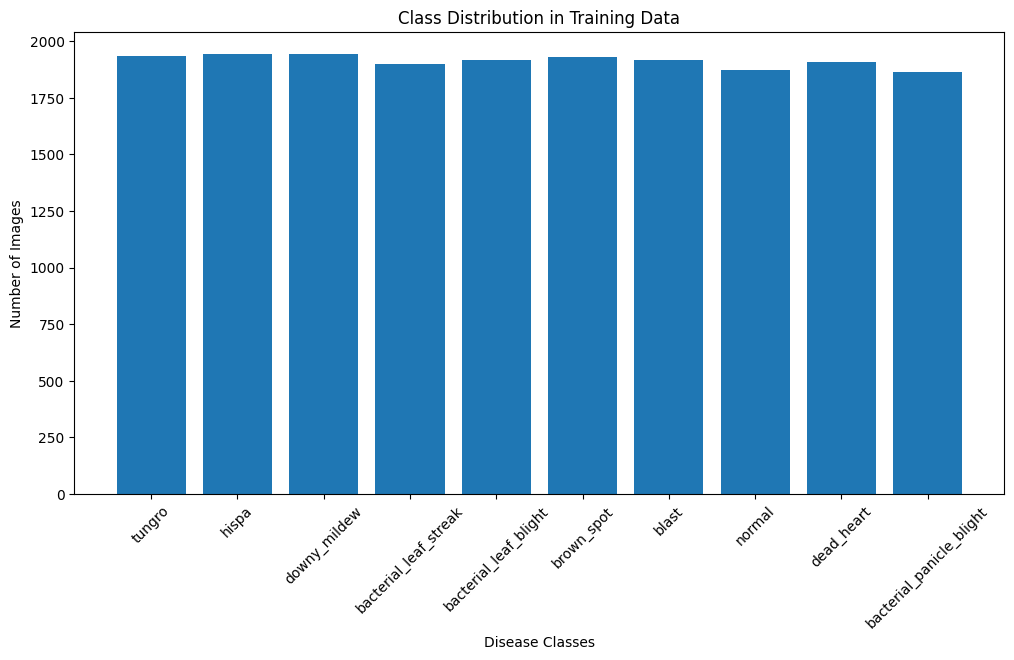

In [ ]:

plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Class Distribution in Training Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'tungro'),
  Text(1, 0, 'hispa'),
  Text(2, 0, 'downy_mildew'),
  Text(3, 0, 'bacterial_leaf_streak'),
  Text(4, 0, 'bacterial_leaf_blight'),
  Text(5, 0, 'brown_spot'),
  Text(6, 0, 'blast'),
  Text(7, 0, 'normal'),
  Text(8, 0, 'dead_heart'),
  Text(9, 0, 'bacterial_panicle_blight')])

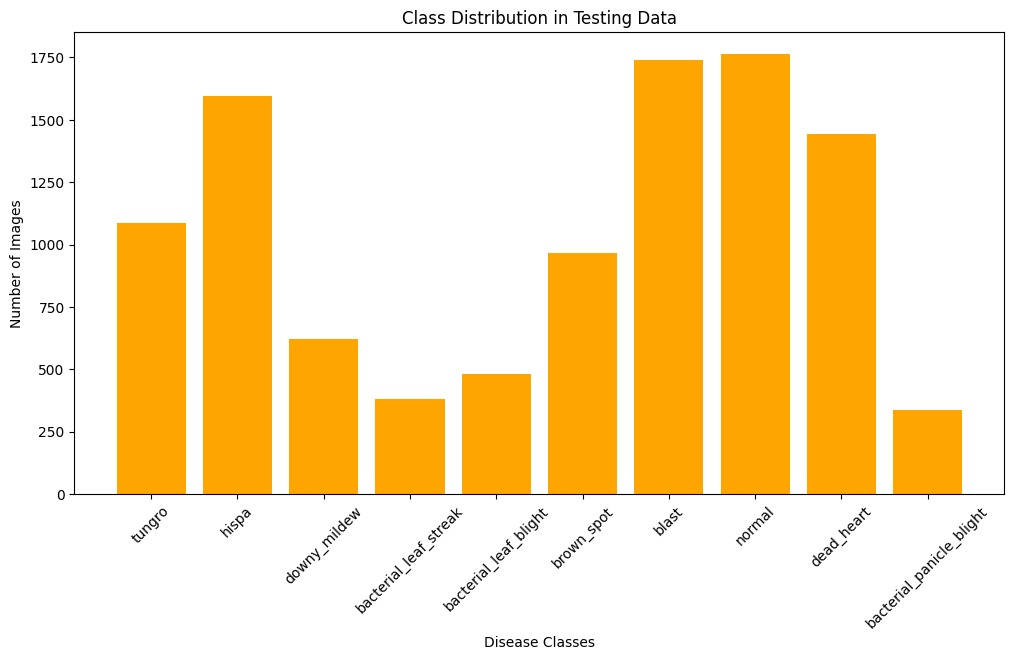

In [ ]:

plt.figure(figsize=(12, 6))
plt.bar(test_counts.keys(), test_counts.values(), color="orange")
plt.title("Class Distribution in Testing Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

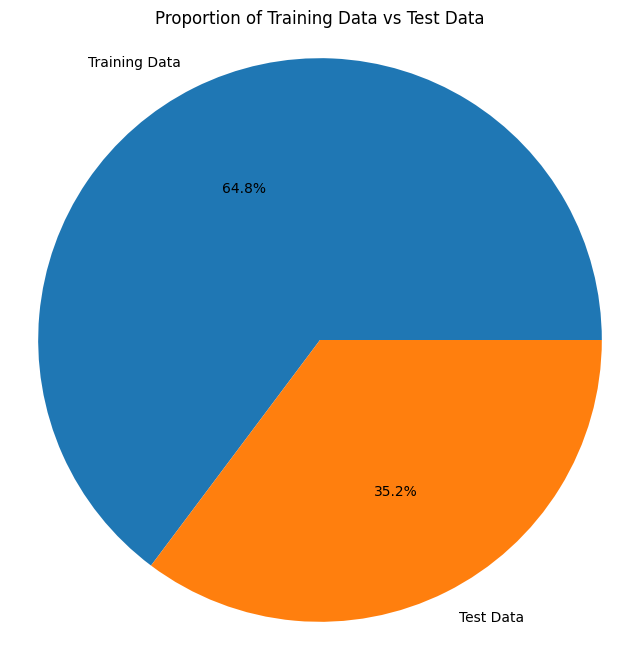

In [ ]:

total_train_images = sum(train_counts.values())
total_test_images = sum(test_counts.values())

labels = ['Training Data', 'Test Data']
sizes = [total_train_images, total_test_images]
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=0)
plt.title("Proportion of Training Data vs Test Data")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:

dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = dataset.class_names
NUM_CLASSES = len(class_names)  # <-- THIS LINE HERE
print(f"Found {NUM_CLASSES} classes: {class_names}")

Found 19131 files belonging to 10 classes.


I0000 00:00:1761158691.268870      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761158691.269587      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 10 classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [ ]:

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1,
                              shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [ ]:

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)
print("Full dataset split (80/10/10):")
print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

Full dataset split (80/10/10):
Train batches: 478
Validation batches: 59
Test batches: 61


In [ ]:

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:

labels = ['Training Data', 'Validation Data', 'Test Data']
sizes = [len(train_ds), len(val_ds), len(test_ds)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

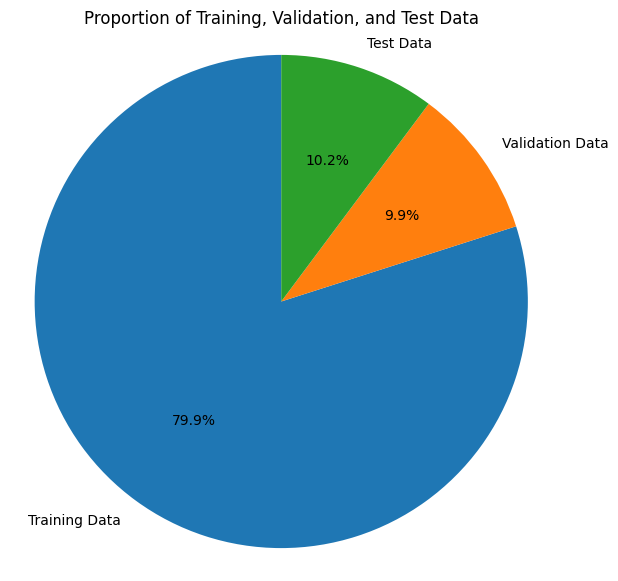

In [ ]:

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Proportion of Training, Validation, and Test Data")
plt.axis('equal')
plt.show()

In [ ]:

resize_and_scale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [ ]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
], name="data_augmentation")

In [ ]:

def build_model(hp):

    #  1. Tune Hyperparameters 
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])
    hp_dense_units = hp.Choice('dense_units', values=[128, 256])
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    hp_filters_3 = hp.Choice('filters_3', values=[64, 128])
    hp_filters_4 = hp.Choice('filters_4', values=[128, 256])

    #  2. Build the Model 
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

        # Preprocessing layers
    
        layers.Rescaling(1./255),
        data_augmentation,

        #  Block 1 (Static) 
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        #  Block 2 (Static) 
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        #  Block 3 (Tunable) 
        layers.Conv2D(hp_filters_3, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        #  Block 4 (Tunable) 
        layers.Conv2D(hp_filters_4, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        #  Classifier Head (Tunable) 
        layers.Flatten(),
        layers.Dense(hp_dense_units, activation='relu'),
        layers.Dropout(hp_dropout),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    #  3. Compile the Model 
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:

# Increased patience  to 7

import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# This rule monitors 'val_loss' with a patience of 7
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [ ]:

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,  # Try 5 different combinations
    executions_per_trial=1, # Train each combination once
    directory='my_tuner_dir',
    project_name='paddy_disease_tuning'
)

In [ ]:

# search on the FULL dataset (train_ds, val_ds)
# epochs (30) to find better hyperparameters.
# Added the early_stopping callback.

print("Starting ROBUST hyperparameter search on FULL dataset...")
tuner.search(
    train_ds,          # <-- Use the FULL tuning set
    epochs=30,         # <-- Use MORE epochs
    validation_data=val_ds,  # <-- Use the FULL validation set
    callbacks=[tensorboard_cb, early_stopping] # <-- Add callbacks
)

Trial 5 Complete [00h 10m 36s]
val_accuracy: 0.8034957647323608

Best val_accuracy So Far: 0.882415235042572
Total elapsed time: 00h 46m 32s


In [ ]:

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Search Complete! ---")
print(f"Best learning rate: {best_hps.get('learning_rate')}")
print(f"Best dense units: {best_hps.get('dense_units')}")
print(f"Best dropout rate: {best_hps.get('dropout')}")
print(f"Best filters (Block 3): {best_hps.get('filters_3')}")
print(f"Best filters (Block 4): {best_hps.get('filters_4')}")


--- Search Complete! ---
Best learning rate: 0.001
Best dense units: 128
Best dropout rate: 0.2
Best filters (Block 3): 128
Best filters (Block 4): 128



--- Analyzing Tuning Results ---
Hyperparameter Tuning Results Table:
   learning_rate  dense_units  dropout  filters_3  filters_4 trial_id  \
2         0.0010          128      0.2        128        128        2   
1         0.0001          256      0.3         64        128        1   
4         0.0001          128      0.4        128        128        4   
0         0.0010          128      0.3        128        256        0   
3         0.0010          128      0.4        128        256        3   

   val_accuracy  
2      0.882415  
1      0.844280  
4      0.803496  
0      0.784428  
3      0.117585  


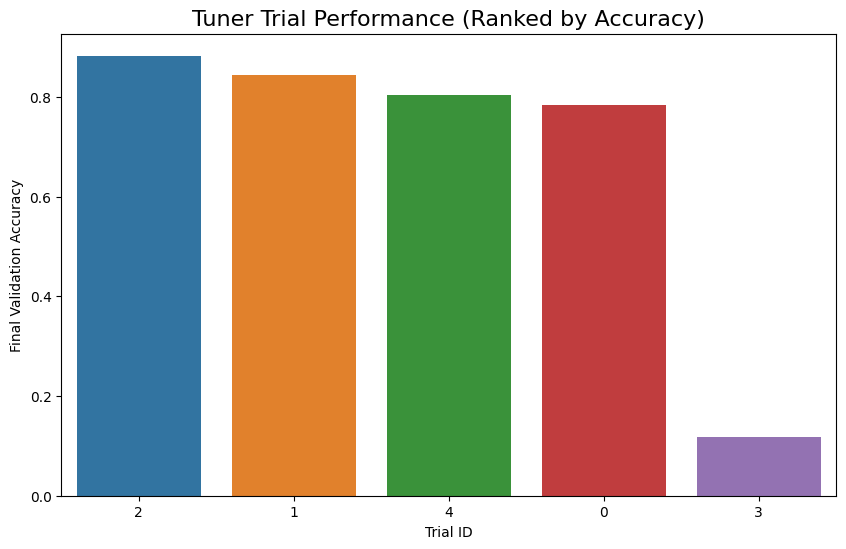

In [ ]:

print("\n--- Analyzing Tuning Results ---")

# Get all the trials
all_trials = tuner.oracle.trials
results = []
for trial_id, trial in all_trials.items():
    if trial.status == 'COMPLETED':
        hps = trial.hyperparameters.values
        score = trial.score
        trial_data = hps.copy()
        trial_data['trial_id'] = trial.trial_id
        trial_data['val_accuracy'] = score
        results.append(trial_data)

# Create a Pandas DataFrame
results_df = pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False)

#  1. The Comparison Table 
print("Hyperparameter Tuning Results Table:")
print(results_df)

#  2. Bar Plot: Ranking of All Trials 
plt.figure(figsize=(10, 6))
sns.barplot(x='trial_id', y='val_accuracy', data=results_df, order=results_df['trial_id'])
plt.title('Tuner Trial Performance (Ranked by Accuracy)', fontsize=16)
plt.xlabel('Trial ID')
plt.ylabel('Final Validation Accuracy')
plt.show()



In [ ]:

#  patience  to 7 for consistency.

model = tuner.hypermodel.build(best_hps)
print("\n--- Final Model Summary ---")
model.summary()


# This rule monitors 'val_loss' with a patience of 7
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
# 2. Train this final model on the FULL, ORIGINAL datasets
EPOCHS = 30

print(f"\nStarting final model training for {EPOCHS} epochs on FULL dataset...")
history = model.fit(
    train_ds, #  Use the FULL 80% dataset
    validation_data=val_ds, #  Use the FULL 10% dataset
    epochs=EPOCHS,
    callbacks=[early_stop]
)
print("Final training complete!")


--- Final Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,234 (4.93 MB)

 Trainable params: 1,291,530 (4.93 MB)

 Non-trainable params: 704 (2.75 KB)


Starting final model training for 30 epochs on FULL dataset...
Epoch 1/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.1977 - loss: 2.5246 - val_accuracy: 0.2394 - val_loss: 2.6521
Epoch 2/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3065 - loss: 1.9194 - val_accuracy: 0.2622 - val_loss: 2.2830
Epoch 3/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.3793 - loss: 1.7304 - val_accuracy: 0.2881 - val_loss: 2.4108
Epoch 4/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4462 - loss: 1.5354 - val_accuracy: 0.4062 - val_loss: 1.7141
Epoch 5/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4999 - loss: 1.3945 - val_accuracy: 0.4306 - val_loss: 1.7558
Epoch 6/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5513 - loss: 1.2357 - val_accuracy: 0.3867 - val_loss: 2.0097
Epoch 7/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5961 - loss: 1.1170 - val_accuracy: 0.5074 - val_loss: 1.4711
Epoch 8/30
478/478 ━━━━━━━


Plotting final model accuracy and loss...


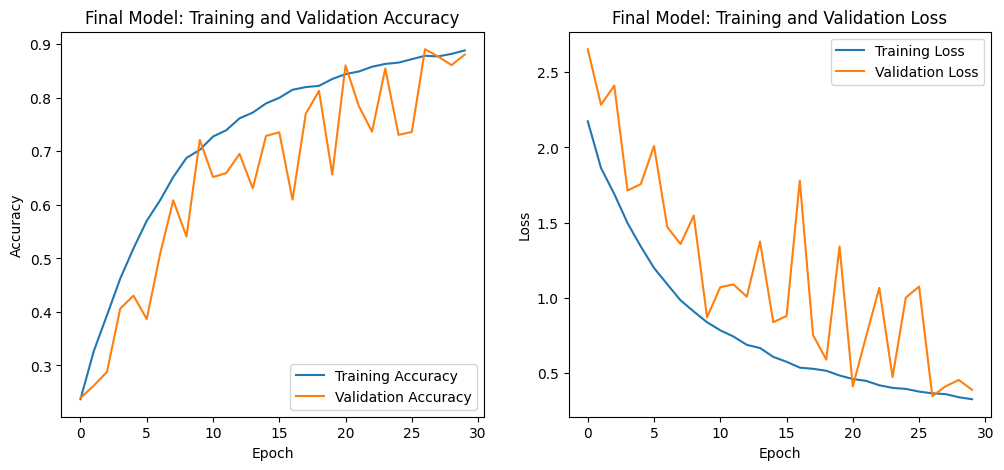

In [ ]:

#  PLOT FINAL MODEL'S TRAINING HISTORY


print("\nPlotting final model accuracy and loss...")

# Get the data from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs that *actually* ran
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

#  Plot Accuracy 
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Final Model: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

#  Plot Loss 
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Final Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [30]:
print("\nEvaluating final model on the unseen test dataset...")
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Evaluating final model on the unseen test dataset...
61/61 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.8886 - loss: 0.3382

Test Loss: 0.3465610444545746
Test Accuracy: 88.99%



Generating Confusion Matrix and Classification Report...
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


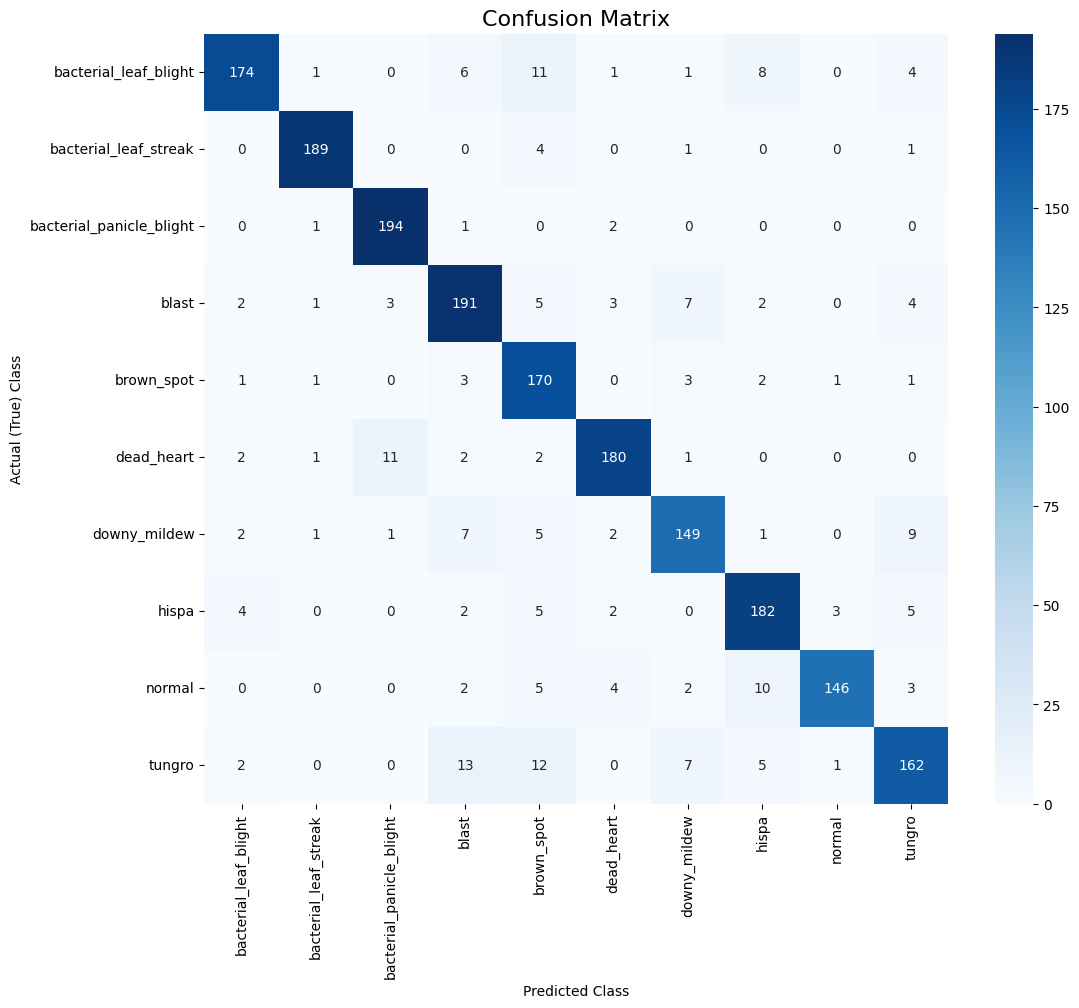


Classification Report:

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.93      0.84      0.89       206
   bacterial_leaf_streak       0.97      0.97      0.97       195
bacterial_panicle_blight       0.93      0.98      0.95       198
                   blast       0.84      0.88      0.86       218
              brown_spot       0.78      0.93      0.85       182
              dead_heart       0.93      0.90      0.92       199
            downy_mildew       0.87      0.84      0.86       177
                   hispa       0.87      0.90      0.88       203
                  normal       0.97      0.85      0.90       172
                  tungro       0.86      0.80      0.83       202

                accuracy                           0.89      1952
               macro avg       0.89      0.89      0.89      1952
            weighted avg       0.89      0.89      0.89      1952



In [ ]:

#  CONFUSION MATRIX & CLASSIFICATION REPORT

print("\nGenerating Confusion Matrix and Classification Report...")

# 1. Get the true labels from the test dataset
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Get the model's predictions
predictions_prob = model.predict(test_ds)

# 3. Convert probabilities to class labels
y_pred = np.argmax(predictions_prob, axis=1)

# 4. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',  # Format annotations as integers
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual (True) Class')
plt.xlabel('Predicted Class')
plt.show()

# 6. Print a detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Visualizing model predictions on a batch of test images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


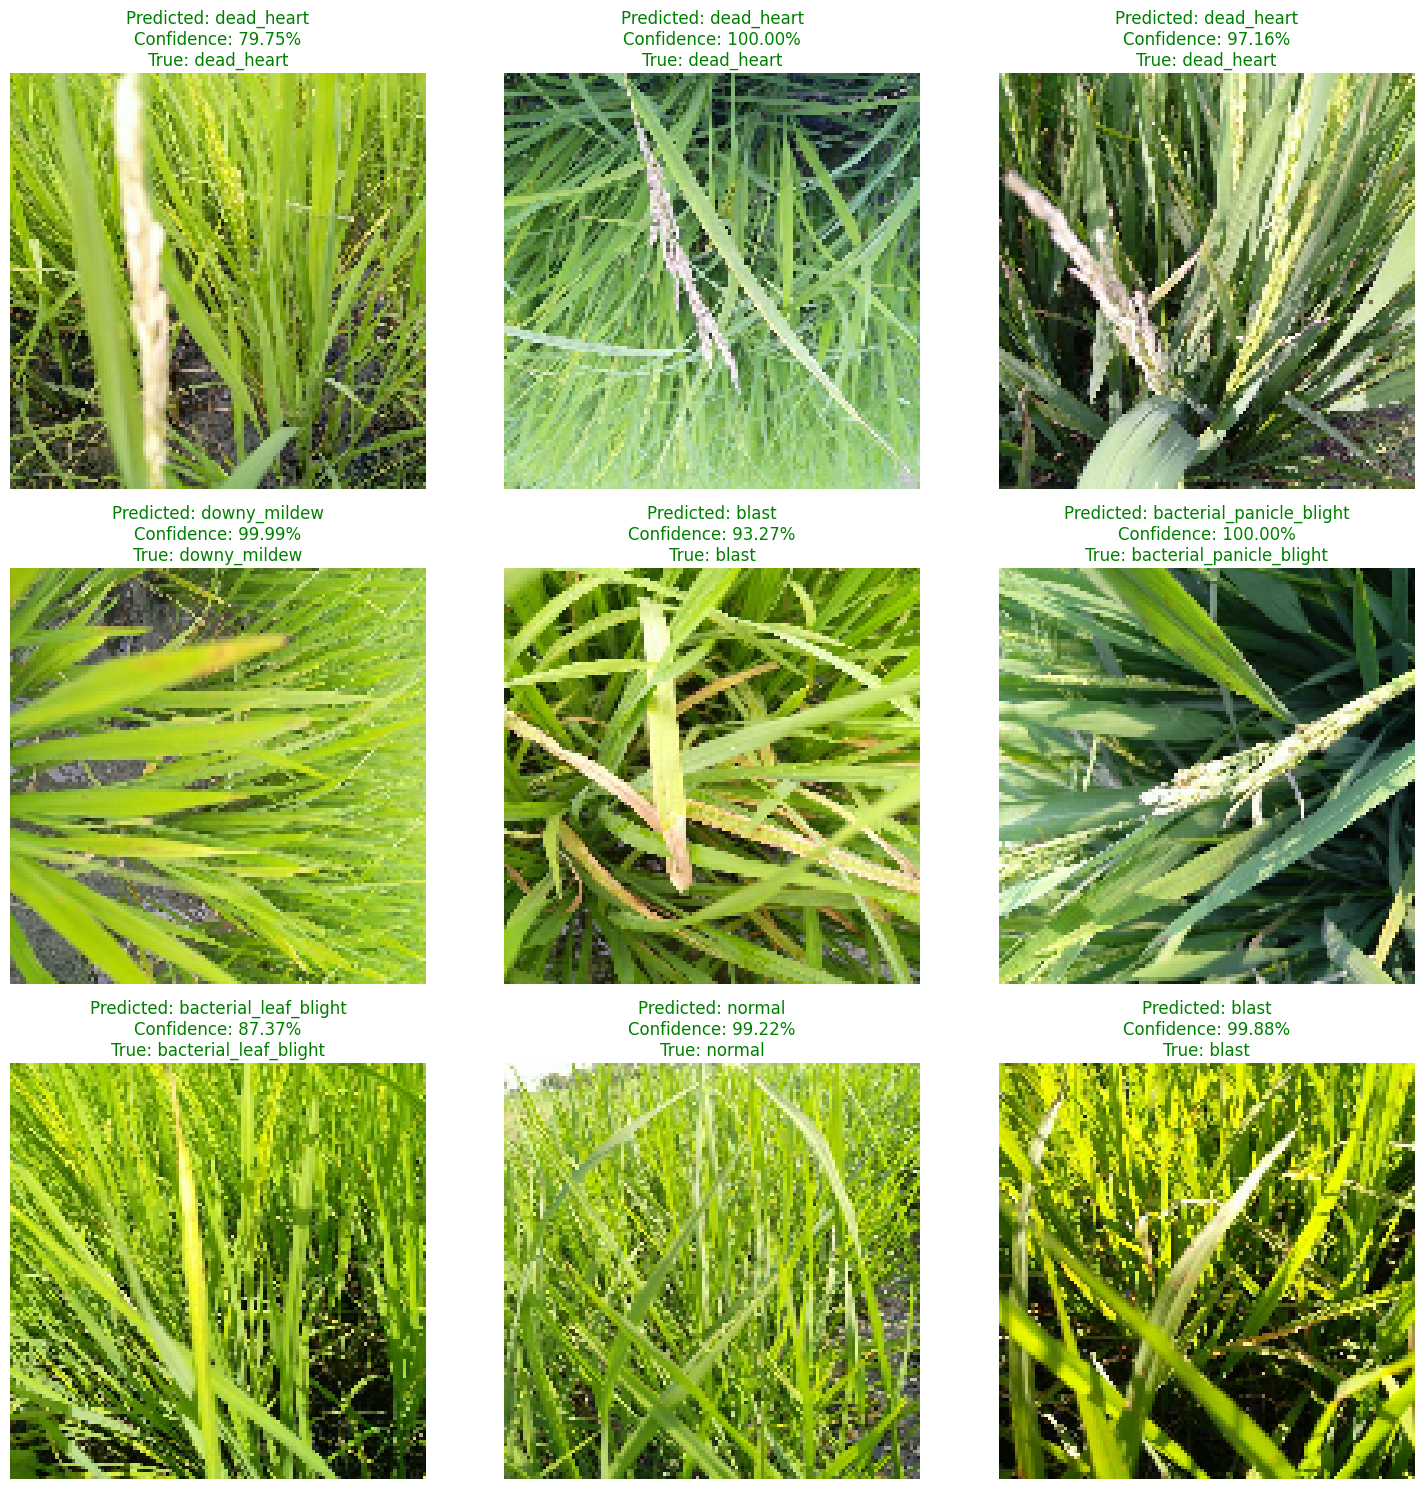

In [ ]:

#  VISUALIZE PREDICTIONS ON TEST IMAGES

print("\nVisualizing model predictions on a batch of test images...")

# 1. Get one batch of test images and labels
image_batch, label_batch = next(iter(test_ds))
image_batch_for_pred = image_batch.numpy()
label_batch_true = label_batch.numpy()

# 2. Get the model's predictions (probabilities)
predictions_prob = model.predict(image_batch_for_pred)

# 3. Get the predicted class index and confidence
y_pred_indices = np.argmax(predictions_prob, axis=1)
confidence_scores = np.max(predictions_prob, axis=1) * 100

# 4. Plot the first 9 images
plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    
   
    img_plot = image_batch[i].numpy().astype("uint8") # Convert to integer for plotting
    true_label_index = label_batch_true[i]
    predicted_label_index = y_pred_indices[i]
    confidence = confidence_scores[i]
    
    plt.imshow(img_plot)
    plt.axis('off')
    
    # Set the title color
    color = "green" if predicted_label_index == true_label_index else "red"
    
    # Create the title
    plt.title(
        f"Predicted: {class_names[predicted_label_index]}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"True: {class_names[true_label_index]}",
        color=color,
        fontsize=12
    )

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


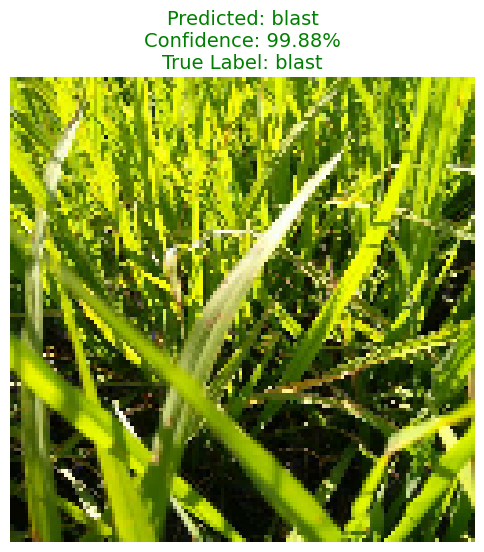

In [ ]:

#  PREDICT ON A SINGLE RANDOM TEST IMAGE


# 1. Get one batch of test images and labels
image_batch, label_batch = next(iter(test_ds))
image_batch_numpy = image_batch.numpy()
label_batch_numpy = label_batch.numpy()

# 2. Pick a random image from that batch
import random
random_index = random.randint(0, len(image_batch_numpy) - 1)

# 3. Get the single image and its true label
img_to_predict = image_batch_numpy[random_index]
true_label_index = label_batch_numpy[random_index]
true_label_name = class_names[true_label_index]

# 4. Prepare the image for the model

img_for_prediction = np.expand_dims(img_to_predict, axis=0)

# 5. Get the model's prediction
prediction_probs = model.predict(img_for_prediction)
predicted_label_index = np.argmax(prediction_probs)
predicted_label_name = class_names[predicted_label_index]
confidence = np.max(prediction_probs) * 100

# 6. Display the image and the result
plt.figure(figsize=(6, 7))
plt.imshow(img_to_predict.astype("uint8")) # Plot the original image
plt.axis('off')

# Set the title color
color = "green" if predicted_label_index == true_label_index else "red"

# Create the title
plt.title(
    f"Predicted: {predicted_label_name}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"True Label: {true_label_name}",
    color=color,
    fontsize=14
)

plt.show()